In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [15]:
from GridMaze.analysis.core import get_clusters as gc

## example cells

In [38]:
example_clusters = [
    "m6.2022-07-02.maze_cluster89",  # left pre
    "m6.2022-07-02.maze_cluster60",  # right pre
    "m6.2022-07-01.maze_cluster116",  # left on
    "m8.2022-07-01.maze_cluster53",  # right on
    "m3.2022-07-15.maze_cluster105",  # left post
    "m8.2022-06-28.maze_cluster26",  # right post
]

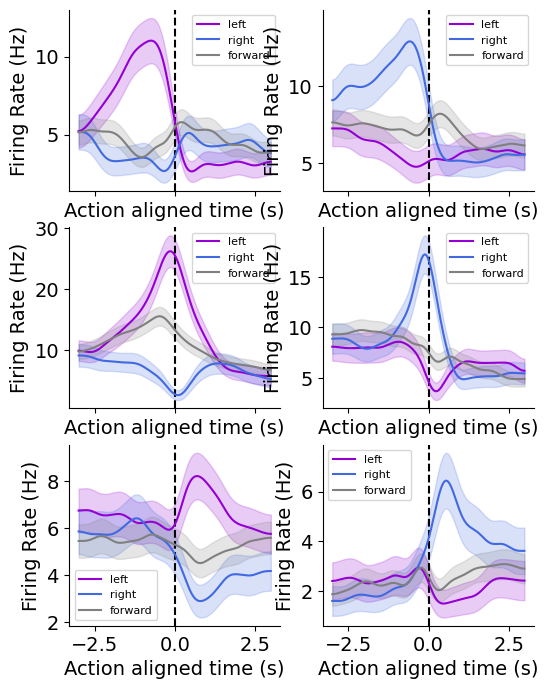

In [42]:
f, axes = plt.subplots(3, 2, figsize=(6, 8), clear=True, sharex=True)
for cluster, ax in zip(example_clusters, axes.flatten()):
    Cluster = gc.get_cluster(cluster)
    Cluster.plot_tuning(
        feature="actions",
        feature_kwargs={
            "concise": True,
            "action_type": "all",
            "smooth_SD": 14,
            "colors": ["darkviolet", "royalblue", "grey"],
        },
        ax=ax,
    )
f.savefig("../results/egocentric_action/example_cells.pdf")

## population heatmap

In [3]:
from GridMaze.analysis.egocentric_action import population_heatmap as eph

In [4]:
tuning_df, metrics_df = eph.get_population_egocentric_action_tuning()

frames.navigation.parquet not found for m3.2022-06-25.maze
frames.spikeRates.parquet not found for m3.2022-06-25.maze
clusters.metrics.htsv not found for m3.2022-06-25.maze
clusters.egocentricActionTuningMetrics.parquet not found for m3.2022-06-25.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.egocentricActionTuningMetrics.parquet not found for m8.2022-07-26.maze


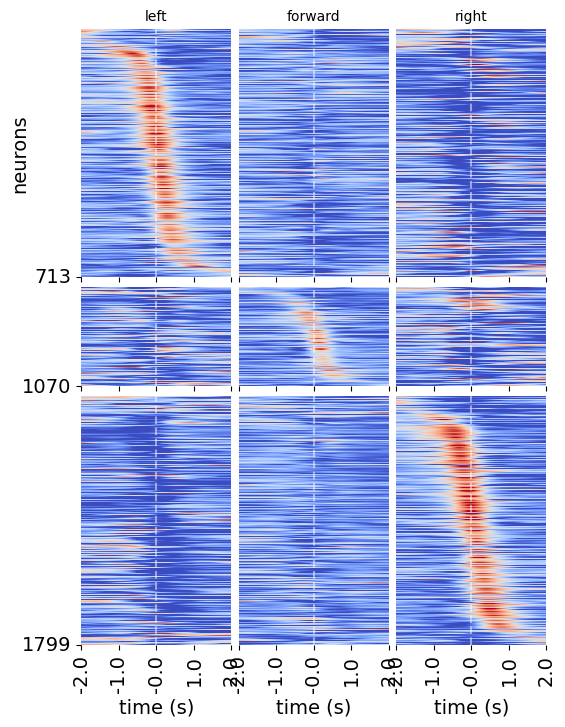

In [43]:
# plot heatmap of action-aligned cells
reload(eph)
f, axes = plt.subplots(3, 3, figsize=(6, 8), height_ratios=[1, 0.4, 1], sharex=True)
eph.plot_egocentric_action_tuning_heatmap(tuning_df, metrics_df, axes=axes, f=f)
f.savefig("../results/egocentric_action/population_heatmap.pdf")

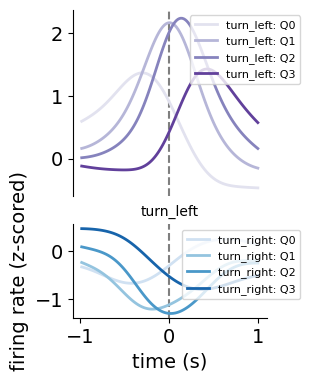

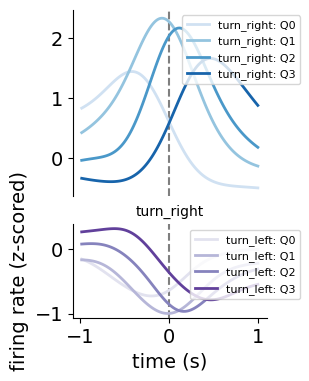

In [48]:
# plot quartiles of these heatmaps to visualise the distribution of tuning relative to action
for action in ["turn_left", "turn_right"]:
    f, axes = plt.subplots(2, 1, figsize=(2.5, 4), height_ratios=[1, 0.5], sharex=False)
    eph.plot_heatmap_quantiles(tuning_df, metrics_df, pref_action=action, n_quantiles=4, axes=axes)
    f.savefig(f"../results/egocentric_action/{action}_heatmap_quantiles.pdf")